In [1]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. GENERATE SYNTHETIC SENSOR DATA (1000 hours of motor operation)
np.random.seed(42)
hours = np.arange(1, 1001)
# Physics simulation: As the motor ages, temp and vibration slowly drift upward
temperature = 60 + (hours * 0.02) + np.random.normal(0, 5, 1000)
vibration = 0.5 + (hours * 0.001) + np.random.normal(0, 0.1, 1000)

# Define failure condition: High temp AND high vibration, with some randomness
failure_probability = (temperature > 75) & (vibration > 1.2)
# 1 = Failure, 0 = Healthy
failure = np.where(failure_probability | (np.random.rand(1000) > 0.95), 1, 0) 

df_motor = pd.DataFrame({'Operating_Hours': hours, 'Temp_C': temperature, 
                         'Vibration_mm_s': vibration, 'Failure': failure})

# 2. PREPARE THE DATA FOR ML
# X = The Inputs (The Sensors)
X = df_motor[['Temp_C', 'Vibration_mm_s']] 
# y = The Target (What we want to predict)
y = df_motor['Failure'] 

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. TRAIN THE AI 
# We initialize 100 decision trees to look at the data
model = RandomForestClassifier(n_estimators=100, random_state=42)
print("Training the model on the 80% dataset...")
model.fit(X_train, y_train)

# 4. PREDICT AND EVALUATE (The "Test Track")
# We hand the AI the 20% of sensor data it has never seen and ask for predictions
predictions = model.predict(X_test)

# Compare the AI's predictions to the actual known failures
accuracy = accuracy_score(y_test, predictions)

print("-" * 30)
print(f"✅ Training Complete!")
print(f"Accuracy on unseen test data: {accuracy * 100:.2f}%")
print("-" * 30)

Training the model on the 80% dataset...
------------------------------
✅ Training Complete!
Accuracy on unseen test data: 94.50%
------------------------------


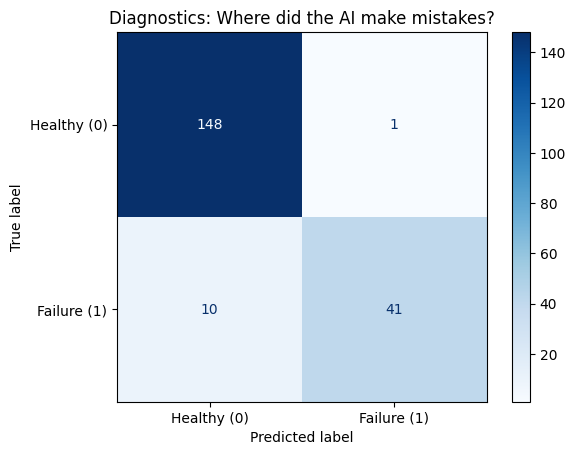

----------------------------------------
SENSOR IMPORTANCE WEIGHTING:
🌡️ Temperature Sensor: 55.3%
📳 Vibration Sensor:   44.7%
----------------------------------------


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. THE CONFUSION MATRIX
# Compares the true labels against the AI's predictions
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Failure (1)'])

disp.plot(cmap='Blues')
plt.title("Diagnostics: Where did the AI make mistakes?")
plt.show()

# 2. FEATURE IMPORTANCE
# Which sensor actually drove the decision?
importances = model.feature_importances_
print("-" * 40)
print("SENSOR IMPORTANCE WEIGHTING:")
print(f"🌡️ Temperature Sensor: {importances[0]*100:.1f}%")
print(f"📳 Vibration Sensor:   {importances[1]*100:.1f}%")
print("-" * 40)

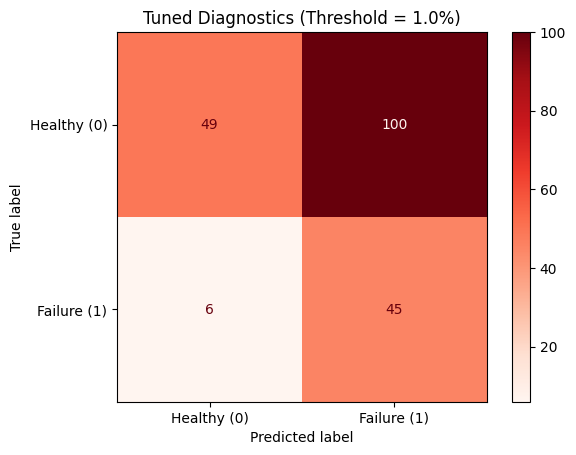

----------------------------------------
⚙️ NEW CALIBRATION RESULTS:
Catastrophic Failures Missed (False Negatives): 6
Healthy Motors Replaced Early (False Positives): 100
----------------------------------------


In [10]:
# 1. GET RAW PROBABILITIES
# predict_proba returns [Probability of 0, Probability of 1]
# We only want the probability of 1 (Failure), which is index [:, 1]
probabilities = model.predict_proba(X_test)[:, 1] 

# 2. SET A STRICTER SAFETY THRESHOLD
# Shift the threshold from the default 50% down to 30%
safety_threshold = 0.01
strict_predictions = (probabilities >= safety_threshold).astype(int)

# 3. EVALUATE THE NEW CALIBRATION
cm_strict = confusion_matrix(y_test, strict_predictions)
disp_strict = ConfusionMatrixDisplay(confusion_matrix=cm_strict, display_labels=['Healthy (0)', 'Failure (1)'])

disp_strict.plot(cmap='Reds')
plt.title(f"Tuned Diagnostics (Threshold = {safety_threshold*100}%)")
plt.show()

# 4. PRINT THE RESULTS
fixed_false_negatives = cm_strict[1][0]
new_false_positives = cm_strict[0][1]

print("-" * 40)
print("⚙️ NEW CALIBRATION RESULTS:")
print(f"Catastrophic Failures Missed (False Negatives): {fixed_false_negatives}")
print(f"Healthy Motors Replaced Early (False Positives): {new_false_positives}")
print("-" * 40)